In [1]:
import pandas as pd
from sdv.tabular import CTGAN
import seaborn as sns

import numpy as np


C:\ProgramData\anaconda3\lib\site-packages\rdt\transformers\base.py:132: FutureWarning: Future versions of RDT will not support the 'model_missing_values' parameter. Please switch to using the 'missing_value_generation' parameter to select your strategy.
  warnings.warn(


In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_excel('IAFREE_Chile.xlsx')

In [4]:
df

,qa1,qa2,qa3,qa4,qa5,qa6,qa7,qa8,qa9,qa10,qa11,qa12,qa13,qa14,qa15,qa16,qa17,qa18,qa19,qa20,qa21,qa22,qa23,qa24,qa25,qa26,qa27,qa28,qa288,qa29,qa30,qa31,qa32,qa33,qa34,qa35,qa36
0,5,1,4,5,5,3,1,1,2,5,1,4,1,1,4,1,1,1,5,5,5,3,4,2,3,2,3,4,2,5,3,1,1,1,3,1,5
1,3,5,2,5,5,4,4,4,5,4,3,4,4,2,5,5,5,5,5,5,5,5,5,5,5,3,2,1,5,5,3,5,1,2,5,3,3
2,1,1,1,3,1,1,1,1,1,3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,5,1,1,1,1,1,1,1,1
3,1,1,5,3,1,4,1,1,1,5,1,1,1,3,5,1,1,1,1,5,3,5,5,1,1,1,1,5,1,3,5,1,1,1,3,1,3
4,3,2,1,2,1,1,1,1,1,3,1,3,1,3,1,1,1,3,4,2,1,1,2,3,1,2,3,4,2,2,1,1,1,1,2,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,2,1,1,1,1,2,1,1,1,2,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,5,1,1,1,1,1,1,1,1,1
163,3,1,5,3,3,3,3,3,2,5,1,4,5,5,1,1,1,1,3,5,1,1,5,3,3,3,1,5,1,5,3,1,5,1,5,5,1
164,1,1,2,1,3,3,3,5,1,3,1,1,1,1,2,3,1,1,1,3,1,2,1,1,1,2,5,5,1,3,2,1,5,1,1,4,1
165,2,3,1,3,2,1,2,1,1,5,3,1,1,3,5,1,3,1,1,2,2,4,3,2,2,4,1,4,2,1,4,1,4,1,3,5,3


In [5]:
df = df.dropna()

In [6]:
quantidade = (df == 2.5).any(axis=1).sum()
print(f"{quantidade} linhas contêm o valor 2.5.")

0 linhas contêm o valor 2.5.


In [7]:

df

,qa1,qa2,qa3,qa4,qa5,qa6,qa7,qa8,qa9,qa10,qa11,qa12,qa13,qa14,qa15,qa16,qa17,qa18,qa19,qa20,qa21,qa22,qa23,qa24,qa25,qa26,qa27,qa28,qa288,qa29,qa30,qa31,qa32,qa33,qa34,qa35,qa36
0,5,1,4,5,5,3,1,1,2,5,1,4,1,1,4,1,1,1,5,5,5,3,4,2,3,2,3,4,2,5,3,1,1,1,3,1,5
1,3,5,2,5,5,4,4,4,5,4,3,4,4,2,5,5,5,5,5,5,5,5,5,5,5,3,2,1,5,5,3,5,1,2,5,3,3
2,1,1,1,3,1,1,1,1,1,3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,5,1,1,1,1,1,1,1,1
3,1,1,5,3,1,4,1,1,1,5,1,1,1,3,5,1,1,1,1,5,3,5,5,1,1,1,1,5,1,3,5,1,1,1,3,1,3
4,3,2,1,2,1,1,1,1,1,3,1,3,1,3,1,1,1,3,4,2,1,1,2,3,1,2,3,4,2,2,1,1,1,1,2,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,2,1,1,1,1,2,1,1,1,2,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,5,1,1,1,1,1,1,1,1,1
163,3,1,5,3,3,3,3,3,2,5,1,4,5,5,1,1,1,1,3,5,1,1,5,3,3,3,1,5,1,5,3,1,5,1,5,5,1
164,1,1,2,1,3,3,3,5,1,3,1,1,1,1,2,3,1,1,1,3,1,2,1,1,1,2,5,5,1,3,2,1,5,1,1,4,1
165,2,3,1,3,2,1,2,1,1,5,3,1,1,3,5,1,3,1,1,2,2,4,3,2,2,4,1,4,2,1,4,1,4,1,3,5,3


In [8]:
from sdv.tabular import GaussianCopula

model = GaussianCopula()
model.fit(df)
synthetic_data = model.sample(1000)
synthetic_data.to_csv("df_sintetico_IAFREE_Chile_GaussianCopula1000.csv", index=False)

C:\ProgramData\anaconda3\lib\site-packages\rdt\transformers\base.py:132: FutureWarning: Future versions of RDT will not support the 'model_missing_values' parameter. Please switch to using the 'missing_value_generation' parameter to select your strategy.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\copulas\univariate\truncated_gaussian.py:45: RuntimeWarning: invalid value encountered in double_scalars
  a = (self.min - loc) / scale
C:\ProgramData\anaconda3\lib\site-packages\copulas\univariate\truncated_gaussian.py:46: RuntimeWarning: divide by zero encountered in double_scalars
  b = (self.max - loc) / scale


In [9]:
# Treina o modelo
model = CTGAN(epochs=600)

# Treina o modelo com os dados prontos
model.fit(df)

# Gera 370 amostras sintéticas
df_sintetico = model.sample(1000)

C:\ProgramData\anaconda3\lib\site-packages\rdt\transformers\base.py:132: FutureWarning: Future versions of RDT will not support the 'model_missing_values' parameter. Please switch to using the 'missing_value_generation' parameter to select your strategy.
  warnings.warn(


Hellinger médio entre dados reais e sintéticos: 0.1257


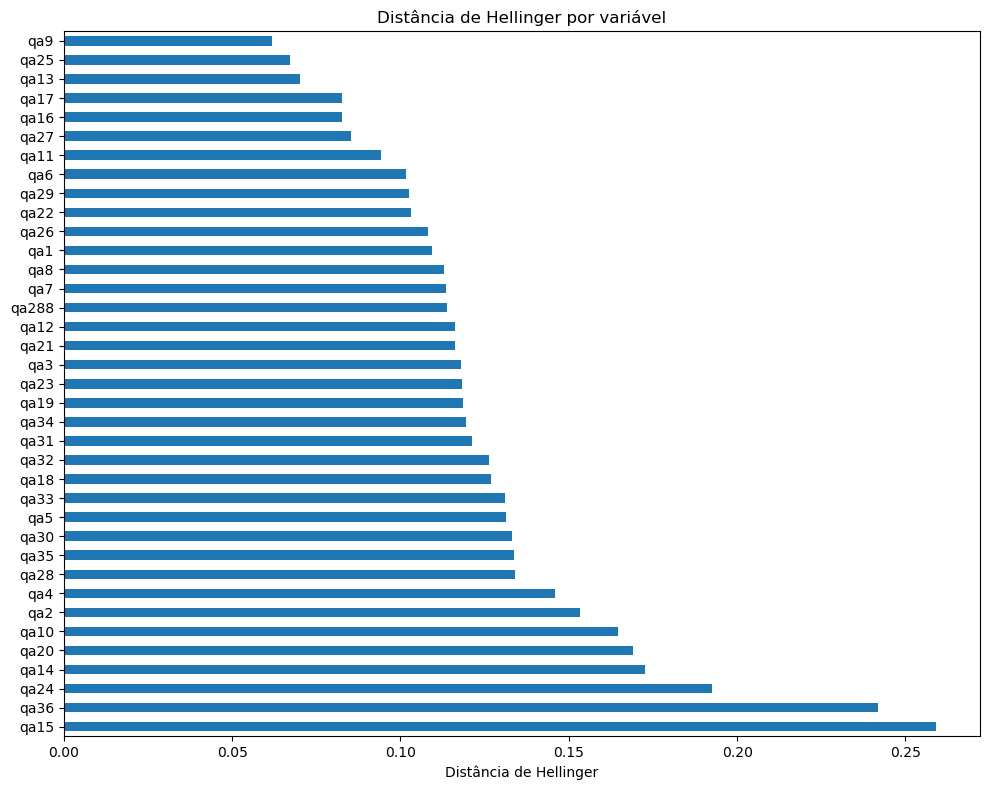

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def hellinger_distance(p, q):
    """Calcula a distância de Hellinger entre duas distribuições discretas normalizadas."""
    p = np.asarray(p) / np.sum(p)
    q = np.asarray(q) / np.sum(q)
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))

# Avalia Hellinger média por coluna
distancias = {}

for col in df.columns:
    real_counts = df[col].value_counts().sort_index()
    sint_counts = df_sintetico[col].value_counts().sort_index()

    # Garante alinhamento dos índices
    all_indices = sorted(set(real_counts.index).union(set(sint_counts.index)))
    real_alinhado = [real_counts.get(i, 0) for i in all_indices]
    sint_alinhado = [sint_counts.get(i, 0) for i in all_indices]

    d = hellinger_distance(real_alinhado, sint_alinhado)
    distancias[col] = d

# Cria DataFrame com os resultados
df_hellinger = pd.DataFrame.from_dict(distancias, orient='index', columns=['Hellinger'])
media = df_hellinger['Hellinger'].mean()

# Ordena para facilitar a leitura
df_hellinger = df_hellinger.sort_values(by='Hellinger', ascending=False)

# Mostra o resultado médio
print(f"Hellinger médio entre dados reais e sintéticos: {media:.4f}")

# (Opcional) Gera gráfico
df_hellinger.plot(kind='barh', figsize=(10, 8), legend=False, title="Distância de Hellinger por variável")
plt.xlabel("Distância de Hellinger")
plt.tight_layout()
plt.show()


In [11]:
df_sintetico.to_csv("df_sintetico_IAFREE_Chile.csv", index=False)

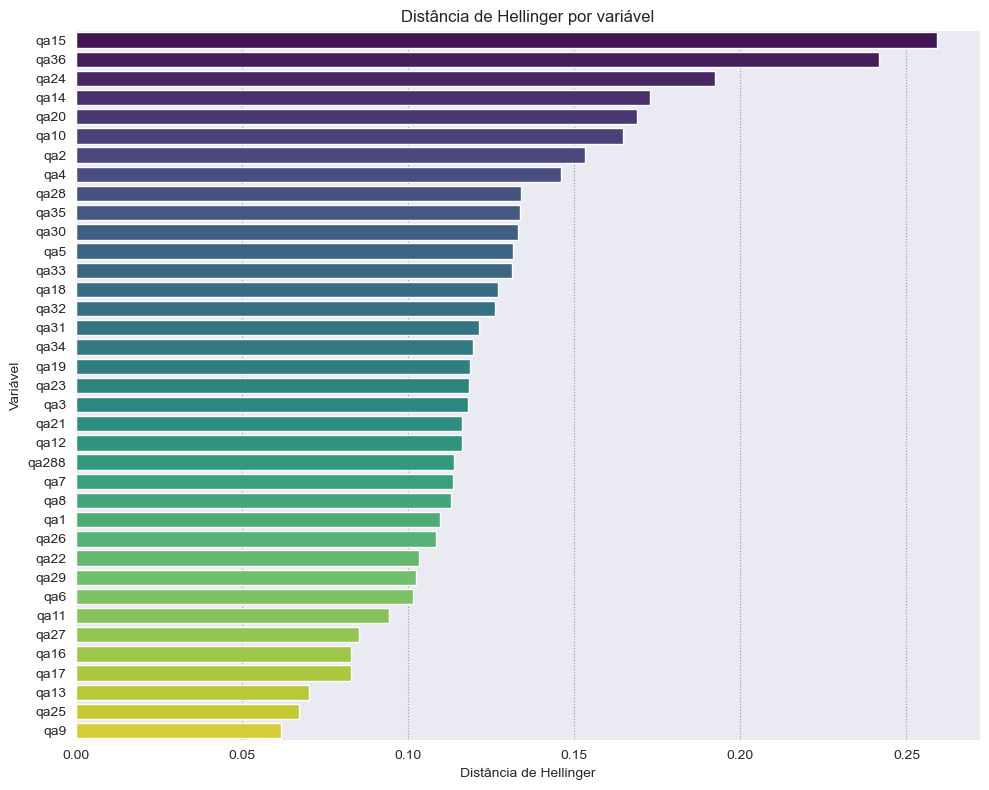

In [12]:
# Define o estilo do Seaborn
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

# Cria o gráfico de barras horizontais
plt.figure(figsize=(10, 8))
sns.barplot(x='Hellinger', y=df_hellinger.index, data=df_hellinger, palette='viridis')

# Adiciona título e rótulo ao eixo x
plt.title("Distância de Hellinger por variável")
plt.xlabel("Distância de Hellinger")
plt.ylabel("Variável")

# Ajusta o layout para melhor visualização
plt.tight_layout()
plt.show()

In [17]:
from sdv.tabular import CopulaGAN

model = CopulaGAN(epochs=300)  # Pode ajustar esse número para mais estabilidade
model.fit(df)
synthetic_data = model.sample(500)

C:\ProgramData\anaconda3\lib\site-packages\rdt\transformers\base.py:132: FutureWarning: Future versions of RDT will not support the 'model_missing_values' parameter. Please switch to using the 'missing_value_generation' parameter to select your strategy.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\rdt\transformers\base.py:132: FutureWarning: Future versions of RDT will not support the 'model_missing_values' parameter. Please switch to using the 'missing_value_generation' parameter to select your strategy.
  warnings.warn(


In [18]:
synthetic_data.to_csv("df_sintetico_IAFREE_Chile_copula.csv", index=False)

In [19]:
from sdv.tabular import GaussianCopula

model = GaussianCopula()
model.fit(df)
synthetic_data = model.sample(500)
synthetic_data.to_csv("df_sintetico_IAFREE_Chile_GaussianCopula.csv", index=False)

C:\ProgramData\anaconda3\lib\site-packages\rdt\transformers\base.py:132: FutureWarning: Future versions of RDT will not support the 'model_missing_values' parameter. Please switch to using the 'missing_value_generation' parameter to select your strategy.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\copulas\univariate\truncated_gaussian.py:45: RuntimeWarning: invalid value encountered in double_scalars
  a = (self.min - loc) / scale
C:\ProgramData\anaconda3\lib\site-packages\copulas\univariate\truncated_gaussian.py:46: RuntimeWarning: divide by zero encountered in double_scalars
  b = (self.max - loc) / scale


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

def comparar_histogramas(df_real, df_sintetico, colunas=None, n_cols=3):
    colunas = colunas or df_real.columns
    n = len(colunas)
    n_rows = -(-n // n_cols)

    plt.figure(figsize=(5*n_cols, 4*n_rows))

    for i, col in enumerate(colunas):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.histplot(df_real[col], bins=[1,2,3,4,5,6], stat='density', kde=False, label='Original', color='blue', alpha=0.6)
        sns.histplot(df_sintetico[col], bins=[1,2,3,4,5,6], stat='density', kde=False, label='Sintético', color='orange', alpha=0.6)
        plt.title(col)
        plt.xticks([1, 2, 3, 4, 5])
        plt.legend()

    plt.tight_layout()
    plt.show()

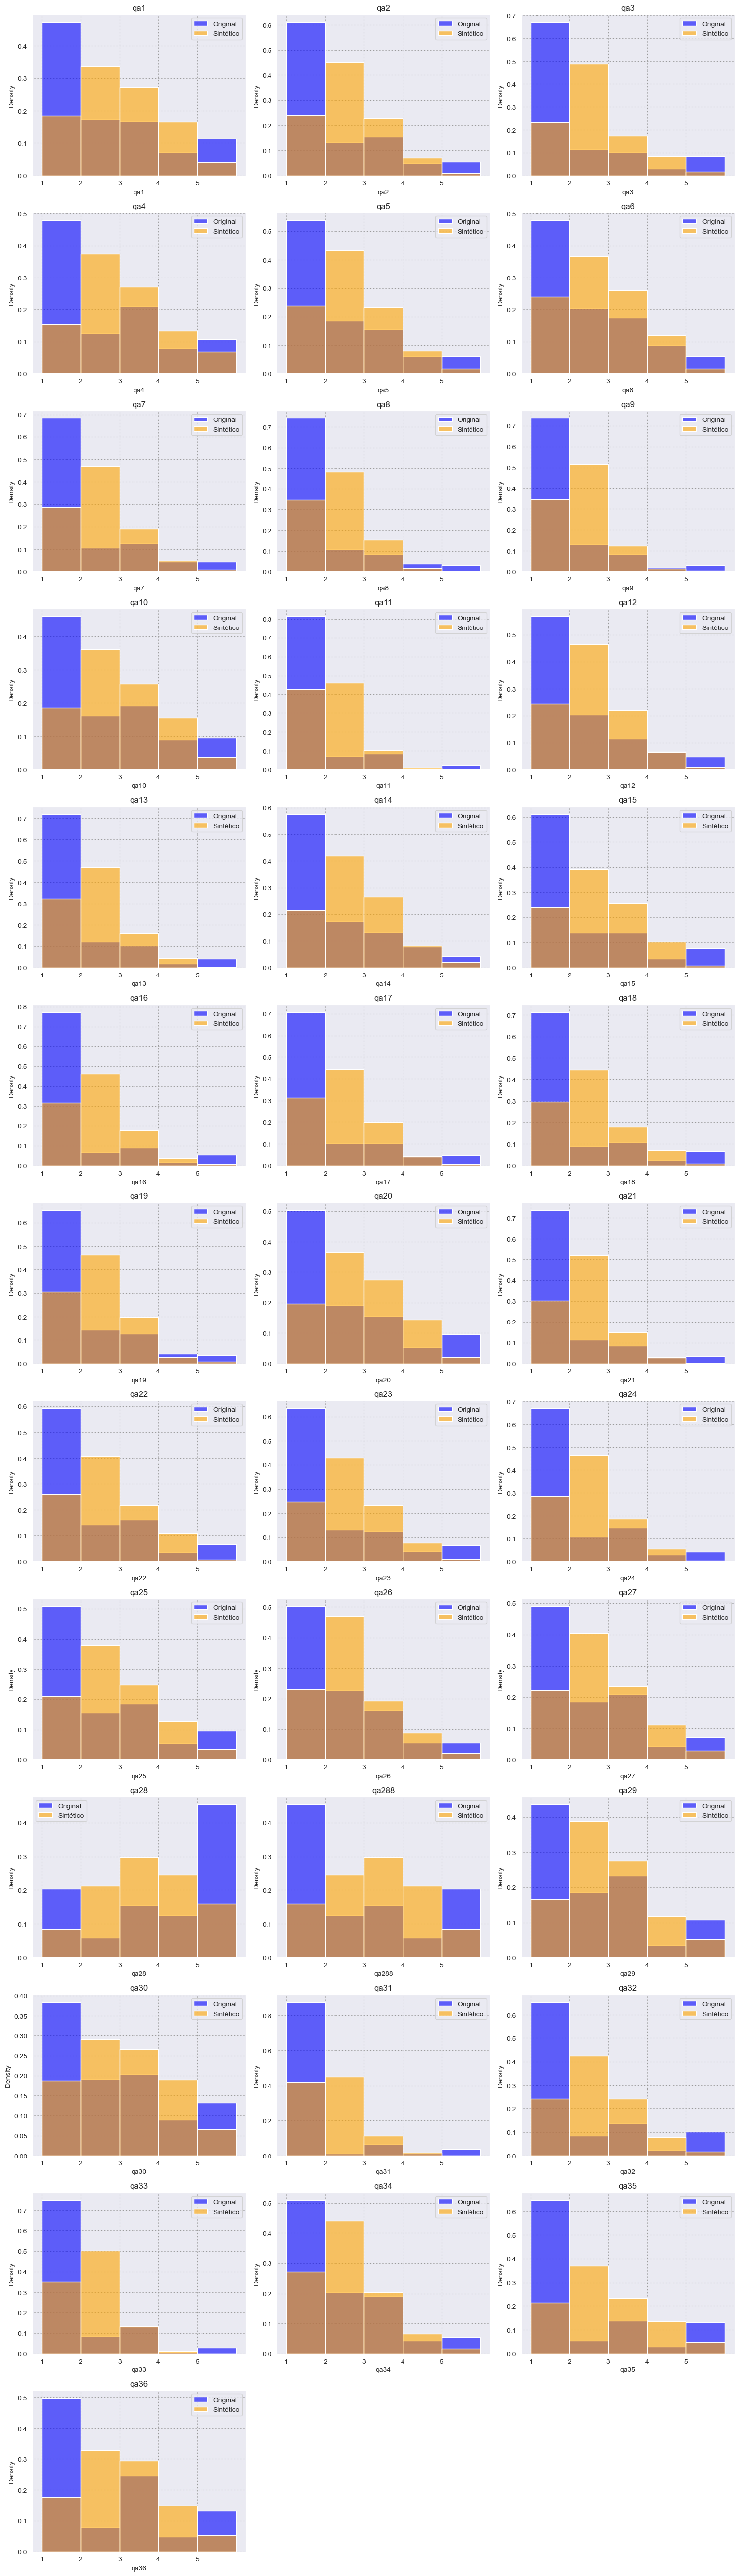

In [21]:
comparar_histogramas(df, synthetic_data)

In [13]:
# Treina o modelo
model = CTGAN(epochs=600)

# Treina o modelo com os dados prontos
model.fit(df)

# Gera 370 amostras sintéticas
df_sintetico = model.sample(500)

C:\ProgramData\anaconda3\lib\site-packages\rdt\transformers\base.py:132: FutureWarning: Future versions of RDT will not support the 'model_missing_values' parameter. Please switch to using the 'missing_value_generation' parameter to select your strategy.
  warnings.warn(


Hellinger médio entre dados reais e sintéticos: 0.1270


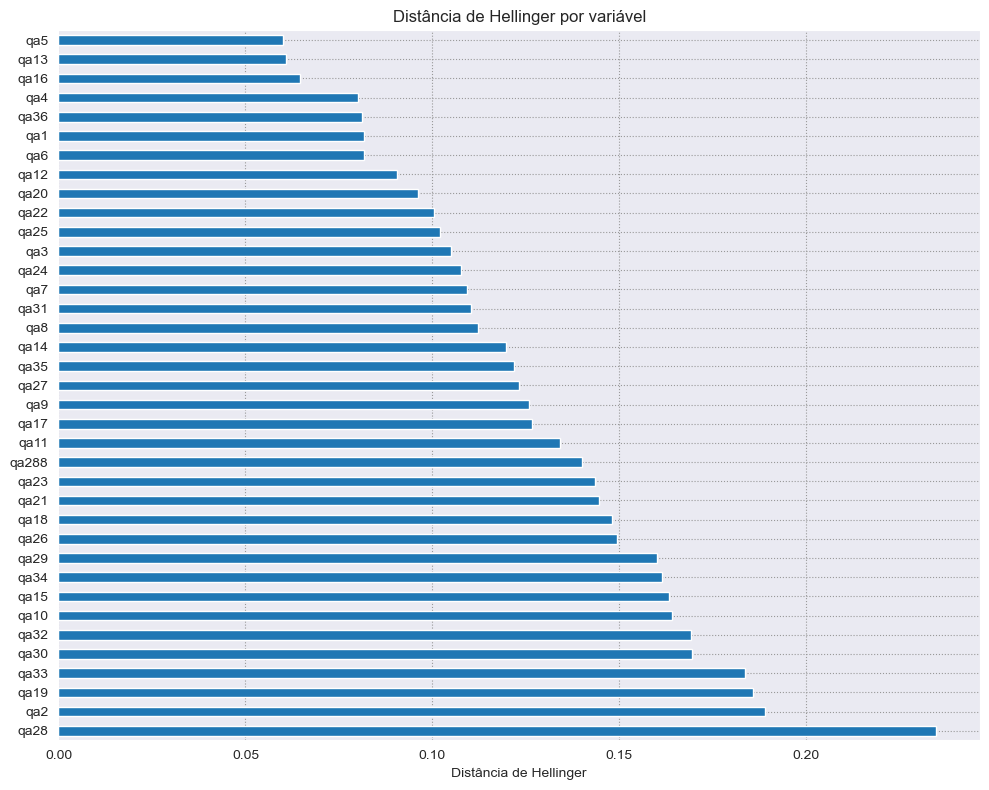

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def hellinger_distance(p, q):
    """Calcula a distância de Hellinger entre duas distribuições discretas normalizadas."""
    p = np.asarray(p) / np.sum(p)
    q = np.asarray(q) / np.sum(q)
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))

# Avalia Hellinger média por coluna
distancias = {}

for col in df.columns:
    real_counts = df[col].value_counts().sort_index()
    sint_counts = df_sintetico[col].value_counts().sort_index()

    # Garante alinhamento dos índices
    all_indices = sorted(set(real_counts.index).union(set(sint_counts.index)))
    real_alinhado = [real_counts.get(i, 0) for i in all_indices]
    sint_alinhado = [sint_counts.get(i, 0) for i in all_indices]

    d = hellinger_distance(real_alinhado, sint_alinhado)
    distancias[col] = d

# Cria DataFrame com os resultados
df_hellinger = pd.DataFrame.from_dict(distancias, orient='index', columns=['Hellinger'])
media = df_hellinger['Hellinger'].mean()

# Ordena para facilitar a leitura
df_hellinger = df_hellinger.sort_values(by='Hellinger', ascending=False)

# Mostra o resultado médio
print(f"Hellinger médio entre dados reais e sintéticos: {media:.4f}")

# (Opcional) Gera gráfico
df_hellinger.plot(kind='barh', figsize=(10, 8), legend=False, title="Distância de Hellinger por variável")
plt.xlabel("Distância de Hellinger")
plt.tight_layout()
plt.show()


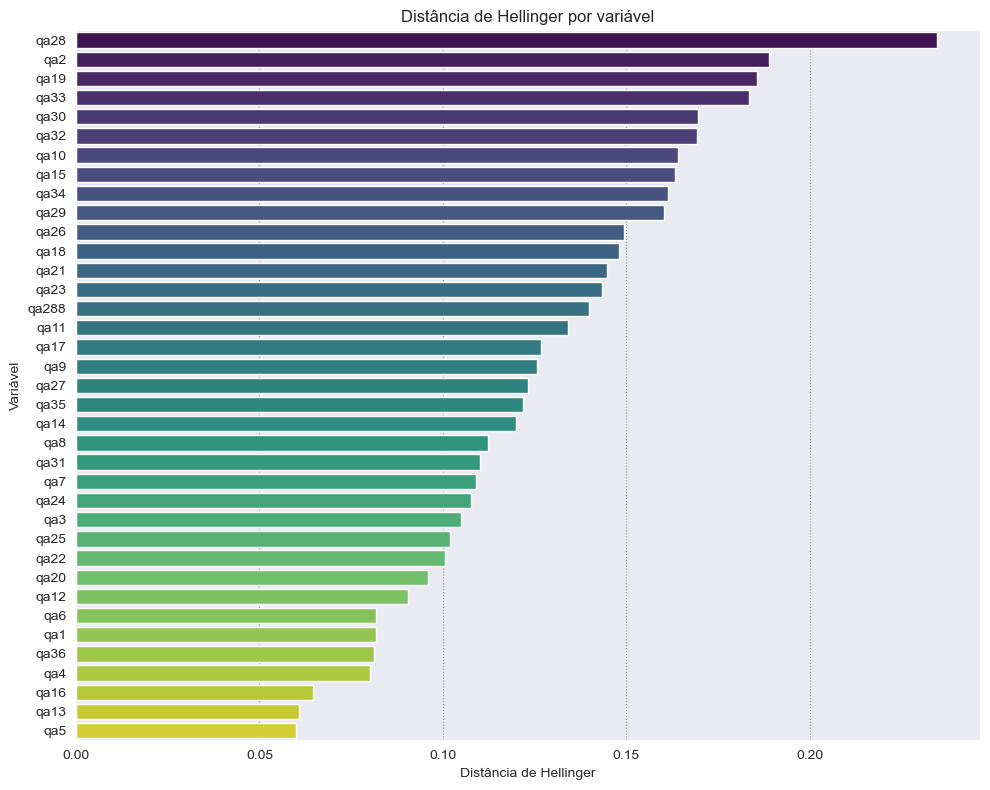

In [15]:
# Define o estilo do Seaborn
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

# Cria o gráfico de barras horizontais
plt.figure(figsize=(10, 8))
sns.barplot(x='Hellinger', y=df_hellinger.index, data=df_hellinger, palette='viridis')

# Adiciona título e rótulo ao eixo x
plt.title("Distância de Hellinger por variável")
plt.xlabel("Distância de Hellinger")
plt.ylabel("Variável")

# Ajusta o layout para melhor visualização
plt.tight_layout()
plt.show()

In [16]:
df_sintetico.to_csv("df_sintetico_IAFREE_Chile500.csv", index=False)

In [14]:
df = df.apply(pd.to_numeric, errors='coerce')
df

,ETI1,ETI2,ETI3,ETI4,ETI5,ETI6,ETI7,ETI8,EAIG1,EAIG2,EAIG3,EAIG4,EAIG5,EAIG6,EAIG7,EAIG8,EAIG9,EAIG10,EEE1,EEE2,EEE3,EEE4,EEE5,EEE6,EEE7,EEE8,EEE9,EEE10,EEE11,EEE12,EEE13,EEE14,EEE15,EEE16,EEE17,EEE18,EEE19,Raça,Idade
0,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3.0,3,2,2.0,2,2.0,2.0,2.0,2.0,2.0,2,2,2,2,2,2,2,2,1.0,40
1,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1.0,1,1,1.0,1,1.0,1.0,4.0,1.0,1.0,1,4,1,4,4,2,1,1,2.0,25
2,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3.0,3,2,2.0,2,2.0,2.0,2.0,2.0,2.0,2,2,2,2,2,2,2,2,2.0,27
3,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3.0,3,2,2.0,2,2.0,2.0,2.0,2.0,2.0,4,4,4,4,4,4,4,4,1.0,20
4,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1.0,1,1,1.0,1,1.0,1.0,4.0,1.0,1.0,1,4,1,4,4,2,1,1,2.0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1.0,1,1,1.0,1,1.0,1.0,4.0,1.0,1.0,1,4,1,4,4,2,1,1,1.0,23
197,7,7,7,7,7,7,7,7,4,5,4,5,5,3,3,4,5,5,2,1.0,1,1,1.0,1,1.0,1.0,2.0,2.0,2.0,2,4,1,2,1,1,1,1,2.0,21
198,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1.0,1,1,1.0,1,1.0,1.0,4.0,1.0,1.0,1,4,1,4,4,2,1,1,1.0,19
199,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3.0,3,2,2.0,2,2.0,2.0,2.0,2.0,2.0,2,2,2,2,2,2,2,2,1.0,23


In [15]:
df['EEE2'] = pd.to_numeric(df['EEE2'], errors='coerce').fillna(-1).astype(int)
df

,ETI1,ETI2,ETI3,ETI4,ETI5,ETI6,ETI7,ETI8,EAIG1,EAIG2,EAIG3,EAIG4,EAIG5,EAIG6,EAIG7,EAIG8,EAIG9,EAIG10,EEE1,EEE2,EEE3,EEE4,EEE5,EEE6,EEE7,EEE8,EEE9,EEE10,EEE11,EEE12,EEE13,EEE14,EEE15,EEE16,EEE17,EEE18,EEE19,Raça,Idade
0,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3,3,2,2.0,2,2.0,2.0,2.0,2.0,2.0,2,2,2,2,2,2,2,2,1.0,40
1,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1,1,1,1.0,1,1.0,1.0,4.0,1.0,1.0,1,4,1,4,4,2,1,1,2.0,25
2,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3,3,2,2.0,2,2.0,2.0,2.0,2.0,2.0,2,2,2,2,2,2,2,2,2.0,27
3,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3,3,2,2.0,2,2.0,2.0,2.0,2.0,2.0,4,4,4,4,4,4,4,4,1.0,20
4,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1,1,1,1.0,1,1.0,1.0,4.0,1.0,1.0,1,4,1,4,4,2,1,1,2.0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1,1,1,1.0,1,1.0,1.0,4.0,1.0,1.0,1,4,1,4,4,2,1,1,1.0,23
197,7,7,7,7,7,7,7,7,4,5,4,5,5,3,3,4,5,5,2,1,1,1,1.0,1,1.0,1.0,2.0,2.0,2.0,2,4,1,2,1,1,1,1,2.0,21
198,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1,1,1,1.0,1,1.0,1.0,4.0,1.0,1.0,1,4,1,4,4,2,1,1,1.0,19
199,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3,3,2,2.0,2,2.0,2.0,2.0,2.0,2.0,2,2,2,2,2,2,2,2,1.0,23


In [17]:
colunas = ['EEE5', 'EEE6', 'EEE7', 'EEE8', 'EEE9', 'EEE10', 'EEE11', 'Raça']

df[colunas] = df[colunas].apply(lambda col: pd.to_numeric(col, errors='coerce').fillna(-1).astype(int))
df

,ETI1,ETI2,ETI3,ETI4,ETI5,ETI6,ETI7,ETI8,EAIG1,EAIG2,EAIG3,EAIG4,EAIG5,EAIG6,EAIG7,EAIG8,EAIG9,EAIG10,EEE1,EEE2,EEE3,EEE4,EEE5,EEE6,EEE7,EEE8,EEE9,EEE10,EEE11,EEE12,EEE13,EEE14,EEE15,EEE16,EEE17,EEE18,EEE19,Raça,Idade
0,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,40
1,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1,1,1,1,1,1,1,4,1,1,1,4,1,4,4,2,1,1,2,25
2,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,27
3,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3,3,2,2,2,2,2,2,2,2,4,4,4,4,4,4,4,4,1,20
4,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1,1,1,1,1,1,1,4,1,1,1,4,1,4,4,2,1,1,2,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1,1,1,1,1,1,1,4,1,1,1,4,1,4,4,2,1,1,1,23
197,7,7,7,7,7,7,7,7,4,5,4,5,5,3,3,4,5,5,2,1,1,1,1,1,1,1,2,2,2,2,4,1,2,1,1,1,1,2,21
198,1,1,1,1,7,1,1,7,5,5,2,5,5,2,2,2,2,5,1,1,1,1,1,1,1,1,4,1,1,1,4,1,4,4,2,1,1,1,19
199,7,7,7,7,7,7,7,7,5,5,5,5,5,5,5,5,5,5,2,3,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,23


In [18]:
df['Raça'].value_counts()

 1    97
 2    56
 3    44
-1     1
Name: Raça, dtype: int64

In [19]:
# Treina o modelo
model = CTGAN(epochs=600)

# Treina o modelo com os dados prontos
model.fit(df)

# Gera 370 amostras sintéticas
df_sintetico = model.sample(1000)

C:\ProgramData\anaconda3\lib\site-packages\rdt\transformers\base.py:132: FutureWarning: Future versions of RDT will not support the 'model_missing_values' parameter. Please switch to using the 'missing_value_generation' parameter to select your strategy.
  warnings.warn(


Hellinger médio entre dados reais e sintéticos: 0.1333


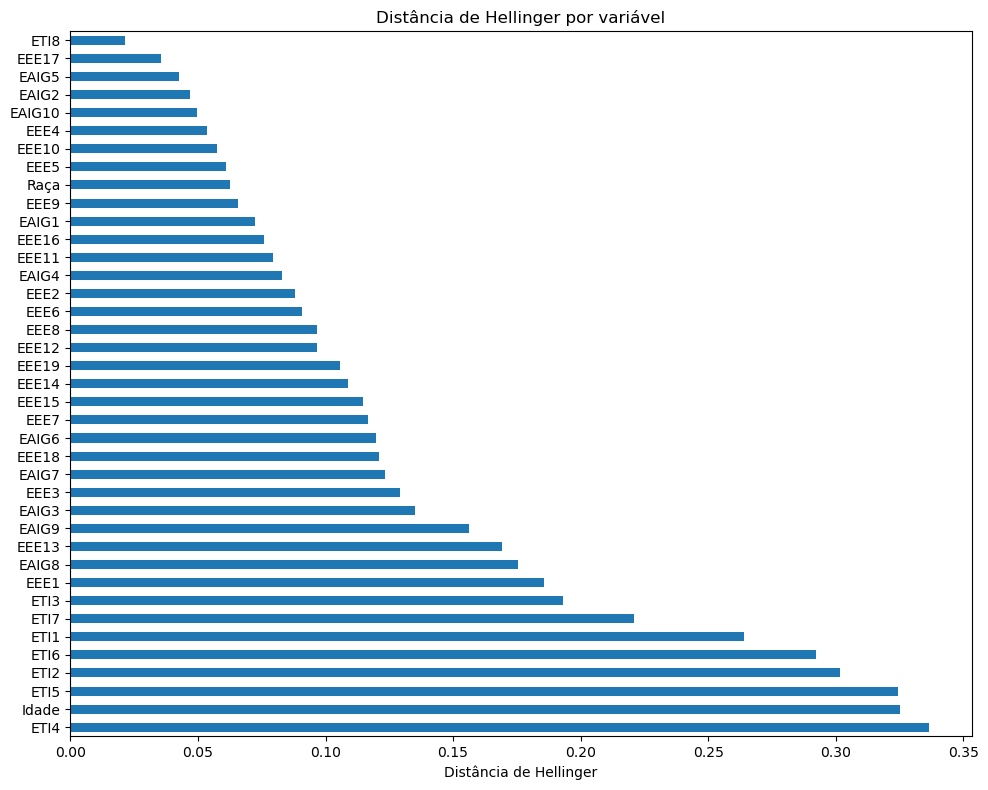

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def hellinger_distance(p, q):
    """Calcula a distância de Hellinger entre duas distribuições discretas normalizadas."""
    p = np.asarray(p) / np.sum(p)
    q = np.asarray(q) / np.sum(q)
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))

# Avalia Hellinger média por coluna
distancias = {}

for col in df.columns:
    real_counts = df[col].value_counts().sort_index()
    sint_counts = df_sintetico[col].value_counts().sort_index()

    # Garante alinhamento dos índices
    all_indices = sorted(set(real_counts.index).union(set(sint_counts.index)))
    real_alinhado = [real_counts.get(i, 0) for i in all_indices]
    sint_alinhado = [sint_counts.get(i, 0) for i in all_indices]

    d = hellinger_distance(real_alinhado, sint_alinhado)
    distancias[col] = d

# Cria DataFrame com os resultados
df_hellinger = pd.DataFrame.from_dict(distancias, orient='index', columns=['Hellinger'])
media = df_hellinger['Hellinger'].mean()

# Ordena para facilitar a leitura
df_hellinger = df_hellinger.sort_values(by='Hellinger', ascending=False)

# Mostra o resultado médio
print(f"Hellinger médio entre dados reais e sintéticos: {media:.4f}")

# (Opcional) Gera gráfico
df_hellinger.plot(kind='barh', figsize=(10, 8), legend=False, title="Distância de Hellinger por variável")
plt.xlabel("Distância de Hellinger")
plt.tight_layout()
plt.show()


In [21]:
df_sintetico.to_csv("df_sintetico_solicitacaoLeogildoeJulio.csv", index=False)

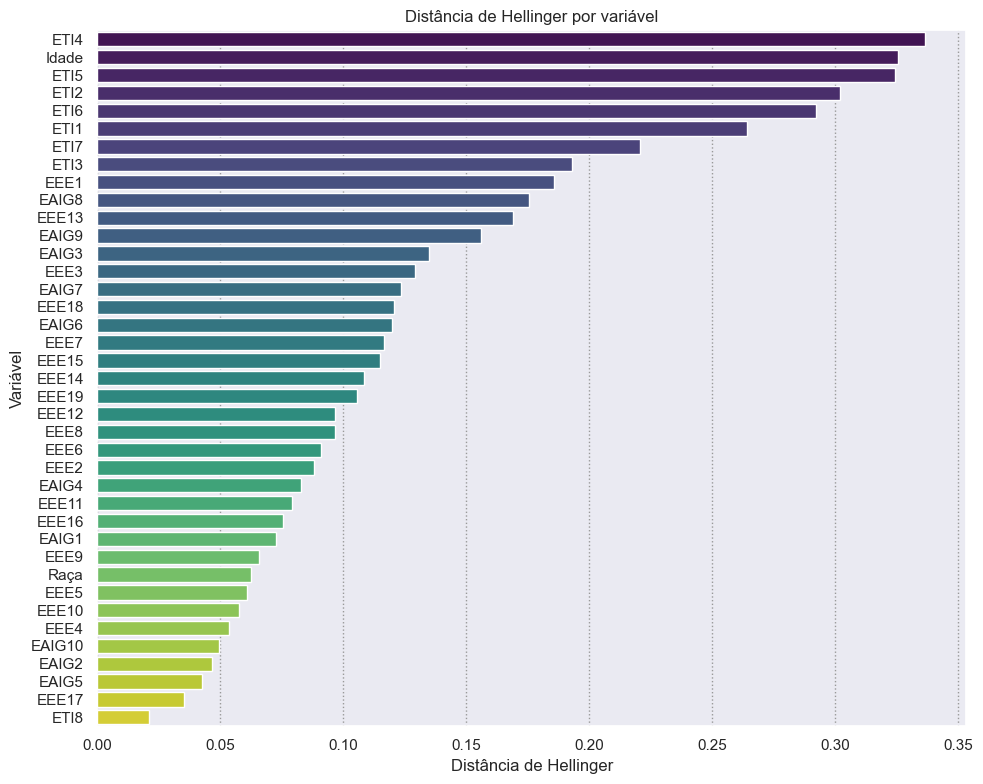

In [25]:
# Define o estilo do Seaborn
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

# Cria o gráfico de barras horizontais
plt.figure(figsize=(10, 8))
sns.barplot(x='Hellinger', y=df_hellinger.index, data=df_hellinger, palette='viridis')

# Adiciona título e rótulo ao eixo x
plt.title("Distância de Hellinger por variável")
plt.xlabel("Distância de Hellinger")
plt.ylabel("Variável")

# Ajusta o layout para melhor visualização
plt.tight_layout()
plt.show()

In [22]:
df_sintetico['Idade'].value_counts()

18    218
23     70
25     63
24     59
21     56
22     50
19     48
27     48
20     47
29     46
26     38
28     36
30     31
31     28
33     26
32     21
44     18
35     17
36     14
34     13
37     11
38      9
42      8
43      7
41      6
40      6
39      6
Name: Idade, dtype: int64

In [ ]:
df['ETI5'].value_counts()

In [ ]:
df_sintetico['ETI5'].value_counts()

In [ ]:
# Treina o modelo
model = CTGAN(epochs=600)

# Treina o modelo com os dados prontos
model.fit(df)

# Gera 370 amostras sintéticas
df_sintetico = model.sample(1000)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def hellinger_distance(p, q):
    """Calcula a distância de Hellinger entre duas distribuições discretas normalizadas."""
    p = np.asarray(p) / np.sum(p)
    q = np.asarray(q) / np.sum(q)
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))

# Avalia Hellinger média por coluna
distancias = {}

for col in df.columns:
    real_counts = df[col].value_counts().sort_index()
    sint_counts = df_sintetico[col].value_counts().sort_index()

    # Garante alinhamento dos índices
    all_indices = sorted(set(real_counts.index).union(set(sint_counts.index)))
    real_alinhado = [real_counts.get(i, 0) for i in all_indices]
    sint_alinhado = [sint_counts.get(i, 0) for i in all_indices]

    d = hellinger_distance(real_alinhado, sint_alinhado)
    distancias[col] = d

# Cria DataFrame com os resultados
df_hellinger = pd.DataFrame.from_dict(distancias, orient='index', columns=['Hellinger'])
media = df_hellinger['Hellinger'].mean()

# Ordena para facilitar a leitura
df_hellinger = df_hellinger.sort_values(by='Hellinger', ascending=False)

# Mostra o resultado médio
print(f"Hellinger médio entre dados reais e sintéticos: {media:.4f}")

# (Opcional) Gera gráfico
df_hellinger.plot(kind='barh', figsize=(10, 8), legend=False, title="Distância de Hellinger por variável")
plt.xlabel("Distância de Hellinger")
plt.tight_layout()
plt.show()


In [ ]:
# Filtra apenas colunas que começam com 'EEE'
df_eee = df[[col for col in df.columns if col.startswith('EEE')]]

# Treina o modelo com as variáveis EEE
model = CTGAN(epochs=600)
model.fit(df_eee)

# Gera 1000 amostras sintéticas
df_sintetico_eee = model.sample(1000)

# Função de distância de Hellinger
def hellinger_distance(p, q):
    """Calcula a distância de Hellinger entre duas distribuições discretas normalizadas."""
    p = np.asarray(p) / np.sum(p)
    q = np.asarray(q) / np.sum(q)
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))

# Avalia Hellinger média por coluna EEE
distancias = {}

for col in df_eee.columns:
    real_counts = df_eee[col].value_counts().sort_index()
    sint_counts = df_sintetico_eee[col].value_counts().sort_index()

    # Garante alinhamento dos índices
    all_indices = sorted(set(real_counts.index).union(set(sint_counts.index)))
    real_alinhado = [real_counts.get(i, 0) for i in all_indices]
    sint_alinhado = [sint_counts.get(i, 0) for i in all_indices]

    d = hellinger_distance(real_alinhado, sint_alinhado)
    distancias[col] = d

# Cria DataFrame com os resultados
df_hellinger = pd.DataFrame.from_dict(distancias, orient='index', columns=['Hellinger'])
media = df_hellinger['Hellinger'].mean()

# Ordena para facilitar a leitura
df_hellinger = df_hellinger.sort_values(by='Hellinger', ascending=False)

# Mostra o resultado médio
print(f"Hellinger médio entre dados reais e sintéticos (EEE): {media:.4f}")

# Gera gráfico
df_hellinger.plot(kind='barh', figsize=(10, 8), legend=False, title="Distância de Hellinger por variável (EEE)")
plt.xlabel("Distância de Hellinger")
plt.tight_layout()
plt.show()

In [ ]:
df_sintetico_eee['EEE11'].value_counts()

In [ ]:
# Filtra apenas colunas que começam com 'EEE'
df_eti = df[[col for col in df.columns if col.startswith('ETI')]]

# Treina o modelo com as variáveis EEE
model = CTGAN(epochs=600)
model.fit(df_eti)

# Gera 1000 amostras sintéticas
df_sintetico_eti = model.sample(1000)

# Função de distância de Hellinger
def hellinger_distance(p, q):
    """Calcula a distância de Hellinger entre duas distribuições discretas normalizadas."""
    p = np.asarray(p) / np.sum(p)
    q = np.asarray(q) / np.sum(q)
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))

# Avalia Hellinger média por coluna EEE
distancias = {}

for col in df_eti.columns:
    real_counts = df_eti[col].value_counts().sort_index()
    sint_counts = df_sintetico_eti[col].value_counts().sort_index()

    # Garante alinhamento dos índices
    all_indices = sorted(set(real_counts.index).union(set(sint_counts.index)))
    real_alinhado = [real_counts.get(i, 0) for i in all_indices]
    sint_alinhado = [sint_counts.get(i, 0) for i in all_indices]

    d = hellinger_distance(real_alinhado, sint_alinhado)
    distancias[col] = d

# Cria DataFrame com os resultados
df_hellinger = pd.DataFrame.from_dict(distancias, orient='index', columns=['Hellinger'])
media = df_hellinger['Hellinger'].mean()

# Ordena para facilitar a leitura
df_hellinger = df_hellinger.sort_values(by='Hellinger', ascending=False)

# Mostra o resultado médio
print(f"Hellinger médio entre dados reais e sintéticos (EEE): {media:.4f}")

# Gera gráfico
df_hellinger.plot(kind='barh', figsize=(10, 8), legend=False, title="Distância de Hellinger por variável (EEE)")
plt.xlabel("Distância de Hellinger")
plt.tight_layout()
plt.show()